In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
sys.path.append("../")

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 10),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from BT.misc import ql_cal_date_range

In [3]:
import datetime

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP

from TB.IRSwapsTB import IRSwapsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.STIRFuturesTB import STIRFuturesTB
from TB.USTFuturesTB import USTFuturesTB
from TB.STIRFutureOptionsTB import STIRFutureOptionsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.STIRFutures.STIRFutureQuery import STIRFutureQuery
from Query.STIRFutures.STIRFutureValue import STIRFutureValue
from Query.USTFutures.USTFutureQuery import USTFutureQuery
from Query.USTFutures.USTFutureValue import USTFutureValue
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

# MDPs
irs_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
frb_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
ustf_mdp = USTFuturesMDP(source="BARCHART_USTF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

# TB routers
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(irs_mdp, show_tqdm=False),
    fixedratebonds_tb=FixedRateBondsTB(frb_mdp, show_tqdm=False),
    stirfutures_tb=STIRFuturesTB(stirf_mdp, show_tqdm=False),
    ustfutures_tb=USTFuturesTB(ustf_mdp, show_tqdm=False),
    stirfutureoptions_tb=STIRFutureOptionsTB(stirfo_mdp, show_tqdm=True),
)

start = datetime.date(2026, 1, 1)
end = datetime.date(2026, 2, 27)

queries = [
    # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.RATE),                 # IRS
    # FixedRateBondQuery(cusip="CT10", value=FixedRateBondValue.YTM),                        # FRB
    # STIRFutureQuery(symbol="SR3H26", curve="USD-SOFR-1D", value=STIRFutureValue.PRICE),   # STIRFUTURE
    # USTFutureQuery(symbol="TYH26", value=USTFutureValue.PRICE),                            # USTFUTURE
    # STIRFutureOptionQuery(symbol="SR3Z27|ATMS", value=STIRFutureOptionValue.PRICE),      # STIRFUTUREOPTION
    STIRFutureOptionQuery(symbol="SR3Z27|ATMS", value=STIRFutureOptionValue.IV_NORMAL_BPS),      # STIRFUTUREOPTION
    # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),                # IRS spread pipeline
]

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=queries,
    drop_multilevel_cols=True,  # set False if you want product-level MultiIndex columns
    # ignore_cache=True 
)
df

PRICING STIR FUTURE OPTIONS.:   2%|▏         | 1/42 [00:11<07:53, 11.55s/it]

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.009249199495105685, `time`: 0.1263s


PRICING STIR FUTURE OPTIONS.:   5%|▍         | 2/42 [00:14<04:14,  6.35s/it]

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.010018000850494677, `time`: 0.1425s


PRICING STIR FUTURE OPTIONS.:   7%|▋         | 3/42 [00:31<07:29, 11.52s/it]

...

2026-03-02 07:00:24,486 - BarchartFetcher - ERROR - Failed to get new token: SOCKSHTTPSConnectionPool(host='www.barchart.com', port=443): Max retries exceeded with url: /futures/quotes/SLU26/interactive-chart (Caused by NewConnectionError('<urllib3.contrib.socks.SOCKSHTTPSConnection object at 0x0000014CC40A8F50>: Failed to establish a new connection: SOCKS5 authentication failed'))
ERROR	Thread(Thread-18 (_worker)) Task(Task-440) BarchartFetcher:BarchartFetcher.py:_fetch_slice()- Failed to get new token: SOCKSHTTPSConnectionPool(host='www.barchart.com', port=443): Max retries exceeded with url: /futures/quotes/SLU26/interactive-chart (Caused by NewConnectionError('<urllib3.contrib.socks.SOCKSHTTPSConnection object at 0x0000014CC40A8F50>: Failed to establish a new connection: SOCKS5 authentication failed'))
2026-03-02 07:00:24,561 - BarchartFetcher - ERROR - Failed to get new token: SOCKSHTTPSConnectionPool(host='www.barchart.com', port=443): Max retries exceeded with url: /futures/quot

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.008922878695295093, `time`: 0.1206s


PRICING STIR FUTURE OPTIONS.: 100%|██████████| 42/42 [04:05<00:00,  5.84s/it]

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.010195576528351942, `time`: 0.1100s


,SR3Z27|ATMS OUTRIGHT IV_NORMAL_BPS
Date,
2026-01-01,83.162738
2026-01-02,83.249369
2026-01-05,81.957574
2026-01-06,79.631670
2026-01-07,79.202213
2026-01-08,79.743501
2026-01-09,76.608651
2026-01-12,76.705807
2026-01-13,74.470198


In [3]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [5]:
# frb_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")

# failed_fedinvest_dates = [
#     datetime.date(2025, 10, 22),
#     datetime.date(2025, 10, 23),
#     datetime.date(2025, 10, 27),
#     datetime.date(2025, 10, 28),
#     datetime.date(2025, 11, 7),
#     datetime.date(2025, 11, 13),
#     datetime.date(2025, 11, 14),
#     datetime.date(2025, 11, 26),
#     datetime.date(2025, 12, 8),
#     datetime.date(2026, 1, 2),
# ]
# for d in failed_fedinvest_dates:
# 	r = frb_mdp.get_pricer(request=dict(cusips=["CT7"], timestamp=d, force_refresh=True))
# 	print(d)

In [4]:
# stb = IRSwapsTB(mdp=IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC"))

# end = datetime.date(2025, 10, 24)
# # start = end - datetime.timedelta(days=90) 
# start = datetime.date(2025, 1, 1) 

# df = stb.get_timeseries(
#     start=start,
#     end=end,
#     queries=[
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="1D", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="1W", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="1M", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="3M", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="6M", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="9M", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="1Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="3Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="7Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.RATE),
#     	IRSwapQuery(curve="USD-SOFR-1D", tenor="20Y", value=IRSwapValue.RATE),
#         IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.RATE),
#     ],
#     n_jobs=1,
#     # ignore_cache=True
# )
# df

In [ ]:
end = datetime.date(2026, 1, 20)
# start = datetime.date(2025, 11, 4)
start = end - datetime.timedelta(days=360) 
# start = datetime.date(2025, 12, 18) 

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="o20/o30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT20", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2/CT5/CT10", value=IRSwapValue.RATE),
        
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.SPREADOVER),
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/5Y/10Y", value=IRSwapValue.CARRY_BPS_RUNNING, value_kwargs={"horizon": "3m"}),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/30Y", value=IRSwapValue.SPREADOVER),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT7", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y", value=IRSwapValue.RATE),

		# FixedRateBondQuery(cusip="CT2/CT10", value=FixedRateBondValue.YTM),
		# FixedRateBondQuery(cusip="CT2/CT10", value=FixedRateBondValue.YTM),
		FixedRateBondQuery(cusip="CT10", value=FixedRateBondValue.YTM),
		FixedRateBondQuery(cusip="CT7", value=FixedRateBondValue.YTM),
		# FixedRateBondQuery(cusip="CT5/CT30", value=FixedRateBondValue.YTM),
		
		# FixedRateBondQuery(cusip="CT2", value=FixedRateBondValue.YTM),
		# FixedRateBondQuery(cusip="CTD_US", value=FixedRateBondValue.YTM),
		# FixedRateBondQuery(cusip="CT2/CT10", value=FixedRateBondValue.YTM),
        
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="3Yx1Y", value=IRSwapValue.RATE)
    ],
    n_jobs=1,
    # ignore_cache=True
)
df

PRICING FIXED-RATE BONDS.: 100%|██████████| 1/1 [00:00<00:00, 87.14it/s]


,CT2/CT10 CURVE YTM
Date,
2025-01-27,32.703919
2025-01-28,34.337640
2025-01-29,31.739926
2025-01-30,31.546330
2025-01-31,35.326762
...,...
2026-01-13,64.715415
2026-01-14,63.224448
2026-01-15,59.200000


In [6]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

plot, fig, ax, ax2, legend = make_secondary_axis_plot(engine="plotly")
# plot, fig, ax, ax2, legend = make_secondary_axis_plot()

plot(
    # df["USD-SOFR-1D CT7 OUTRIGHT MMSS"],
    # df["USD-SOFR-1D CT5 OUTRIGHT MMSS"],
    # df["USD-SOFR-1D CT2/CT5/CT30 FLY MMSS"],
    # df["USD-SOFR-1D 10Y OUTRIGHT RATE"],
    
	# df["USD-SOFR-1D 5Y/30Y CURVE SPREADOVER"],
	# df["USD-SOFR-1D 5Y OUTRIGHT RATE"],
	df["CT2/CT10 CURVE YTM"],
	
	# df["CT10 OUTRIGHT YTM"],
	# df["CT30 OUTRIGHT YTM"],
	# df["CT5/CT30 CURVE YTM"],
	
    which="left",
    indicators=[
        # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        # {"kind": "sma", "window": 252, "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
		# {"kind": "hurst", "hide": True},
		# {"kind": "vol", "returns": "normal", "window": 120, "hide": True},
        
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)

# plot(df["USD-SOFR-1D oo20/oo30 CURVE MMSS"])
# plot(df["CT2/CT5/CT10 FLY YTM"], which="right")
# plot(df["USD-SOFR-1D CT5/CT30 CURVE MMSS"], which="right")
# plot(df["USD-SOFR-1D CT5 OUTRIGHT MMSS"], which="right")
# plot(df["USD-SOFR-1D 30Y OUTRIGHT RATE"], which="right")

# plot(d["USD-SOFR-1D 2Y OUTRIGHT RATE"])

legend(show_date=True)
plt.show()


# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])

Beta: [0.00961574 0.64782965]
Beta Std Error: [0.06565212 0.04213208]
Beta Covariance: [[63434.56628998 -1531.0388822 ]
 [-1531.0388822  26124.87339698]]
Residual Variance: 6.794720127322127e-08
Inverse Condition #: 0.7314707634653334
Reason(s) for Halting:
  Sum of squares convergence


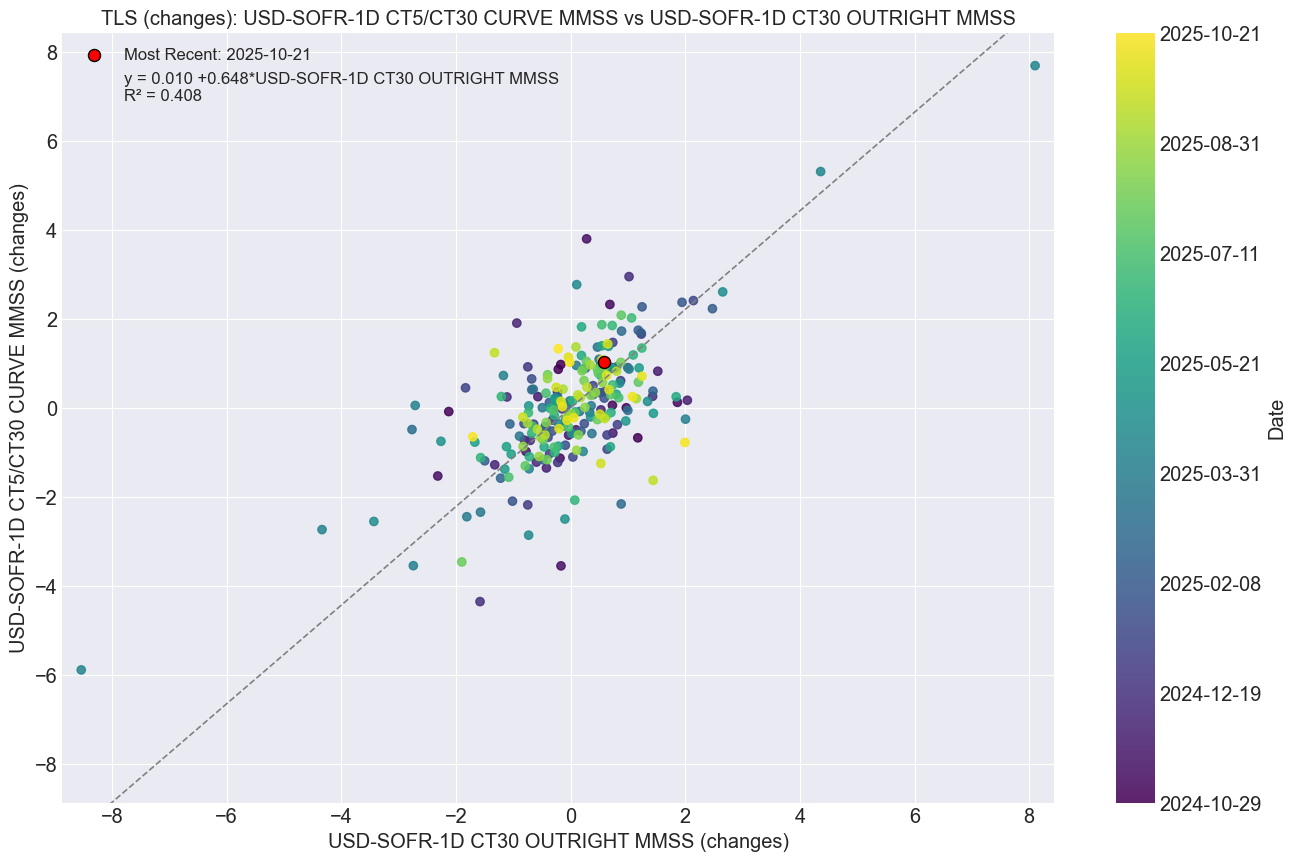

In [37]:
# from RVUtils.regression import make_linear_regression_builder
# from RVUtils.arbl_hedge_ratios import get_tls_hedge_ratio

# add_x, fit, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
#     df=df["SWAPSPREADS"], y_col="USD-SOFR-1D CT30 OUTRIGHT MMSS", date_color_bar=True, on_diff=True
# )
# add_x("USD-SOFR-1D CT5 OUTRIGHT MMSS")

# res = fit(model="TLS", verbose=True)
# plot_avp()
# # plot_resid_ts(
# #     # plot_zscores=True,
# #     # stds=(1, 2),
# #     ou_bands=True,
# #     ou_steps=126,
# # )

from RVUtils.regression import make_linear_regression_builder
import gs_quant.timeseries.econometrics as gsqtse

add_x, fit_, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
    df=df,
    y_col="USD-SOFR-1D CT5/CT30 CURVE MMSS",
    date_color_bar=True,
    on_diff=True,
    add_constant=True,
)

add_x("USD-SOFR-1D CT30 OUTRIGHT MMSS")
_ = fit_(model="OLS")
X_used, y_used, _ = get_data()
X_no_const = X_used.drop(columns=["const"], errors="ignore")

def rvol_abs(s, w=60, floor=1e-8):
    v = gsqtse.volatility(x=s, w=w, returns_type=gsqtse.Returns.ABSOLUTE)
    return v.reindex(y_used.index).bfill().clip(lower=floor)

sx = np.column_stack([rvol_abs(X_no_const[c]).values for c in X_no_const.columns])
sy = rvol_abs(y_used).values

res_deming = fit_(model="TLS", tls_x_errs=sx, tls_y_errs=sy, verbose=True)
plot_avp()

In [5]:
add_x, fit, pavp, prvp, prts, get_data, rolling_beta, rolling_r2, rolling_corr = make_linear_regression_builder(
    df=df,
    y_col="USD-SOFR-1D CT5/CT30 CURVE MMSS",
    date_color_bar=True,
    on_diff=True,
    add_constant=True,
    window=120,
)

x = "USD-SOFR-1D CT30 OUTRIGHT MMSS"
add_x(x)
fit(model="OLS")

plot, fig, ax, ax2, legend = make_secondary_axis_plot()
# plot(rolling_beta(name=x), which="left")
plot(rolling_corr(name=x), which="right")
# plot(rolling_r2(name=x), which="right")
legend(show_date=True)
plt.show()

NameError: name 'make_linear_regression_builder' is not defined

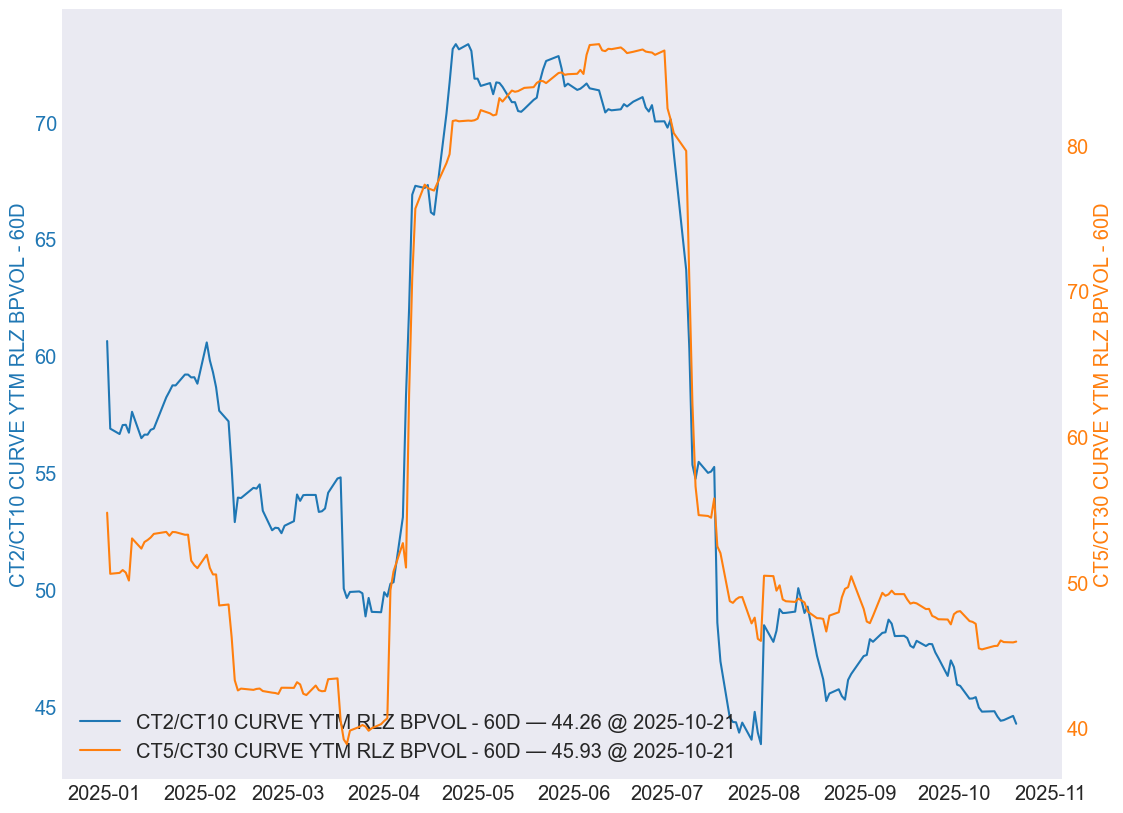

In [ ]:
import gs_quant.timeseries.econometrics as gsqtse

from RVUtils.plt_timeseries import make_secondary_axis_plot

plot, fig, ax, ax2, legend = make_secondary_axis_plot()
	
rv1 = gsqtse.volatility(x=df["CT2/CT10 CURVE YTM"], w=60, returns_type=gsqtse.Returns.ABSOLUTE) / 100
rv2 = gsqtse.volatility(x=df["CT5/CT30 CURVE YTM"], w=60, returns_type=gsqtse.Returns.ABSOLUTE) / 100

plot(
    rv1[rv1.index > datetime.date(2025, 1, 1)],
    which="left",
    indicators=[
        # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        # {"kind": "sma", "window": 252, "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
		# {"kind": "hurst", "hide": True},
		# {"kind": "vol", "returns": "normal", "window": 252, "hide": True},
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
    label="CT2/CT10 CURVE YTM RLZ BPVOL - 60D",
)

plot(rv2[rv2.index > datetime.date(2025, 1, 1)], which="right", label="CT5/CT30 CURVE YTM RLZ BPVOL - 60D")
# plot(df["USD-SOFR-1D 30Y OUTRIGHT RATE"], which="right")
# plot(df["USD-SOFR-1D 30Y OUTRIGHT RATE"], which="right")

# plot(d["USD-SOFR-1D 2Y OUTRIGHT RATE"])

legend(show_date=True, loc="lower left")
plt.show()

In [16]:
import re
from RVUtils.seasonality_utils import monthend_cumsum_seasonality

# seasonality_df = monthend_cumsum_seasonality(df[df.index > datetime.date(2025, 1, 1)].dropna(), window=20)
seasonality_df = monthend_cumsum_seasonality(df[["USD-SOFR-1D CT5/CT30 CURVE MMSS"]].dropna(), window=10)
display(seasonality_df)

fig = go.Figure()

# me_col = f"avg"
me_col = "avg-nov"
line_w = 1.25
min_op = 0.35
max_op = 0.85

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=seasonality_df.index,
        y=seasonality_df[me_col],
        mode="lines",
        name=f"{me_col}",
        line=dict(color="green", width=3),
    )
)
fig.add_hline(y=0, line_width=0.5, line_dash="dash", line_color="red")
if f"{me_col}+std1" in seasonality_df.columns and f"{me_col}-std1" in seasonality_df.columns:
    fig.add_trace(go.Scatter(x=seasonality_df.index, y=seasonality_df[f"{me_col}+std1"], mode="lines", line=dict(width=0), showlegend=False))
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[f"{me_col}-std1"],
            mode="lines",
            line=dict(width=0),
            fill="tonexty",
            fillcolor="rgba(0, 255, 0, 0.10)",
            name="±1σ (template)",
        )
    )

# n_last = 12
# monthly_cols = [c for c in seasonality_df.columns if isinstance(c, str) and re.fullmatch(r"\d{4}-\d{2}", c)]
# monthly_cols = sorted(monthly_cols)  # chronological
# keep = monthly_cols[-n_last:] if n_last > 0 else []

keep = ["2024-11", "2023-11", "2022-11", "2021-11", "2020-11"]

alphas = np.linspace(min_op, max_op, num=len(keep)) if keep else []
palette = px.colors.qualitative.Dark24 if hasattr(px.colors.qualitative, "Dark24") else px.colors.qualitative.Plotly
for i, col in enumerate(keep):
    fig.add_trace(
        go.Scatter(
            x=seasonality_df.index,
            y=seasonality_df[col],
            mode="lines",
            name=col,  # legend shows 'YYYY-MM'
            opacity=float(alphas[i]),
            line=dict(width=line_w, color=palette[i % len(palette)]),
        )
    )

fig.update_layout(
    xaxis_title=f"BDays from {me_col}",
    yaxis_title="Cum Delta",
    title=f"Seasonality: template={me_col}  |  last {len(keep)} months",
    showlegend=True,
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.01,
            y=1.10,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Hide months", method="update", args=[{"visible": [True, True, True] + [False] * len(keep)}]),
                dict(label="Show months", method="update", args=[{"visible": [True, True, True] + [True] * len(keep)}]),
            ],
        )
    ],
)
fig.update_xaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikemode="across", showgrid=True)
fig.update_yaxes(showspikes=True, spikecolor="white", spikesnap="cursor", spikethickness=0.5, showgrid=True)

fig.show(config={"modeBarButtonsToAdd": ["drawline", "drawopenpath", "drawclosedpath", "drawcircle", "drawrect", "eraseshape"]})

,avg,avg-std1,avg+std1,avg-std2,avg+std2,avg-jan,avg-jan-std1,avg-jan+std1,avg-jan-std2,avg-jan+std2,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
bdays_from_month_end,,,,,,,,,,,,,,,,,,,,,
-10,0.034969,-3.459479,3.529418,-6.953928,7.023866,0.583948,-1.605641,2.773538,-3.79523,4.963127,...,1.74199,4.121619,4.714258,1.44247,1.764084,-0.304628,-0.084764,2.298872,-0.253968,0.0
-9,-0.099355,-2.956227,2.757516,-5.813098,5.614388,0.931624,-1.03747,2.900718,-3.006564,4.869812,...,2.635839,2.933813,4.139444,-1.41596,1.674335,-0.872378,-0.194916,2.165749,-1.880245,0.304693
-8,0.306784,-2.723538,3.337105,-5.753859,6.367426,0.142712,-1.573263,1.858687,-3.289238,3.574663,...,2.937615,2.573733,4.501028,1.356164,1.806853,0.319179,0.588358,2.178132,-0.637557,1.110663
-7,0.355244,-2.419595,3.130083,-5.194433,5.904922,0.351015,-1.282368,1.984399,-2.915751,3.617782,...,2.585154,2.951584,3.867895,-1.193576,1.03915,-0.678881,0.887567,2.75033,-0.875445,1.372414
-6,0.006411,-2.414628,2.427449,-4.835666,4.848487,-0.000472,-2.021878,2.020933,-4.043283,4.042338,...,3.238342,1.373516,1.527183,-1.046168,0.002404,-1.795195,2.97238,1.88624,-1.079557,1.349793
-5,0.452052,-1.723536,2.627639,-3.899124,4.803227,0.843984,-0.613863,2.301832,-2.071711,3.759679,...,2.885654,0.961788,1.532953,1.562757,0.893203,-1.538902,1.671742,2.234445,-1.218641,1.203126
-4,0.457935,-1.628571,2.54444,-3.715077,4.630946,0.966579,-0.490356,2.423515,-1.947292,3.88045,...,3.229561,0.420928,2.489165,2.120507,0.023862,-3.61055,2.251496,2.895886,-0.754321,<NA>
-3,0.526949,-1.436927,2.490825,-3.400803,4.454701,1.874803,-0.04857,3.798177,-1.971944,5.72155,...,2.392495,0.685534,0.045209,1.713176,1.421987,-2.263374,1.538247,2.235717,-2.000933,<NA>
-2,0.338441,-1.577763,2.254645,-3.493967,4.170848,1.025981,-0.062113,2.114075,-1.150207,3.20217,...,1.872252,0.751711,0.094355,2.697436,1.730913,-2.369977,2.585547,1.14601,-0.560303,<NA>
